# Hands On Sistem Rekomendasi Film

Notebook ini dibuat untuk mengimplementasikan tiga pendekatan populer dalam sistem rekomendasi:
1. **Demographic Filtering** (Rekomendasi berdasarkan popularitas dan nilai rating rata-rata menggunakan rumus weighted rating IMDB).
2. **Content-Based Filtering** (Rekomendasi berdasarkan kemiripan konten/metadata film seperti genre, sutradara, pemain utama, kata kunci tema, dan overview ringkasan cerita).
3. **Collaborative Filtering** (Rekomendasi personalisasi menggunakan Deep Learning Keras Embedding berbasis interaksi user-item).

---

## 1. Persiapan Data & Preprocessing

Langkah awal adalah mengimpor seluruh library yang dibutuhkan serta memuat dataset (`movies_metadata.csv`, `credits.csv`, `keywords.csv`). Kita akan melakukan pembersihan data pada kolom ID agar proses penggabungan (merge) data berjalan lancar.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.19.0


### Membaca Dataset

Kita memuat data utama metadata film, data cast & crew (credits), serta data kata kunci (keywords).

In [2]:
# Load datasets
movies_path = "data/movies_metadata.csv"
credits_path = "data/credits.csv"
keywords_path = "data/keywords.csv"

movies = pd.read_csv(movies_path, low_memory=False)
credits = pd.read_csv(credits_path)
keywords = pd.read_csv(keywords_path)

print("Movies Metadata shape:", movies.shape)
print("Credits shape:", credits.shape)
print("Keywords shape:", keywords.shape)

Movies Metadata shape: (45466, 24)
Credits shape: (45476, 3)
Keywords shape: (46419, 2)


### Pembersihan ID dan Penggabungan Data

Kolom `id` di `movies_metadata` sering kali memiliki data kotor (berupa string non-angka atau tanggal). Kita akan memaksanya menjadi numerik dan membuang baris yang tidak valid agar bertipe integer yang serasi dengan `credits` dan `keywords`.

In [3]:
# Bersihkan ID di movies_metadata
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id'])
movies['id'] = movies['id'].astype('int64')

# Pastikan ID di dataset lain bertipe integer
credits['id'] = credits['id'].astype('int64')
keywords['id'] = keywords['id'].astype('int64')

# Merge datasets
df = movies.merge(credits, on='id').merge(keywords, on='id')
df = df.drop_duplicates(subset=['id'])

print("Merged Dataset shape:", df.shape)
df.head(2)

Merged Dataset shape: (45432, 27)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,keywords
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1..."


---

## 2. Demographic Filtering

Sistem rekomendasi ini bersifat umum untuk semua user. Prinsip utamanya adalah merekomendasikan film terpopuler dengan rating rata-rata terbaik.

Kita menggunakan formula **Weighted Rating IMDB** untuk memastikan film dengan rating tinggi namun vote yang sedikit tidak mengungguli film dengan rating sedikit lebih rendah tetapi didukung oleh ribuan suara.

$$W = \frac{v}{v+m} \times R + \frac{m}{v+m} \times C$$

Di mana:
- $v$ adalah jumlah vote untuk film (`vote_count`).
- $m$ adalah ambang batas minimum vote agar film dianggap valid (kita ambil persentil ke-90).
- $R$ adalah nilai rating rata-rata film (`vote_average`).
- $C$ adalah rata-rata rating keseluruhan dari seluruh dataset film.

In [4]:
# Hitung C (rata-rata rating global)
C = df['vote_average'].mean()
print("Rata-rata Rating Global (C):", C)

# Tentukan m (jumlah minimum vote, kita gunakan persentil ke-90)
m = df['vote_count'].quantile(0.90)
print("Minimum Vote (m):", m)

Rata-rata Rating Global (C): 5.61845297056946
Minimum Vote (m): 160.0


### Memfilter Film dan Menghitung Skor Rating Tertimbang

Kita memfilter film-film yang memenuhi kriteria minimum vote $m$ ke dalam variabel `qualified_movies`, kemudian membuat kolom baru `score` menggunakan fungsi `weighted_rating`.

In [5]:
# Saring film yang memenuhi syarat minimum vote
qualified_movies = df.copy().loc[df['vote_count'] >= m]

def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m) * R) + (m/(m+v) * C)

# Hitung skor weighted rating
qualified_movies['score'] = qualified_movies.apply(weighted_rating, axis=1)

# Urutkan berdasarkan skor tertinggi
qualified_movies = qualified_movies.sort_values('score', ascending=False)

# Tampilkan Top 10 film
qualified_movies[['title', 'vote_count', 'vote_average', 'score']].head(10)

,title,vote_count,vote_average,score
314,The Shawshank Redemption,8358.0,8.5,8.445874
841,The Godfather,6024.0,8.5,8.425445
10397,Dilwale Dulhania Le Jayenge,661.0,9.1,8.421501
12589,The Dark Knight,12269.0,8.3,8.265480
2870,Fight Club,9678.0,8.3,8.256389
292,Pulp Fiction,8670.0,8.3,8.251410
522,Schindler's List,4436.0,8.3,8.206648
23868,Whiplash,4376.0,8.3,8.205413
5529,Spirited Away,3968.0,8.3,8.196064
2231,Life Is Beautiful,3643.0,8.3,8.187182


### Visualisasi Top 10 Film

Visualisasi ini memperlihatkan film-film dengan skor popularitas tertimbang paling tinggi berdasarkan rating global.

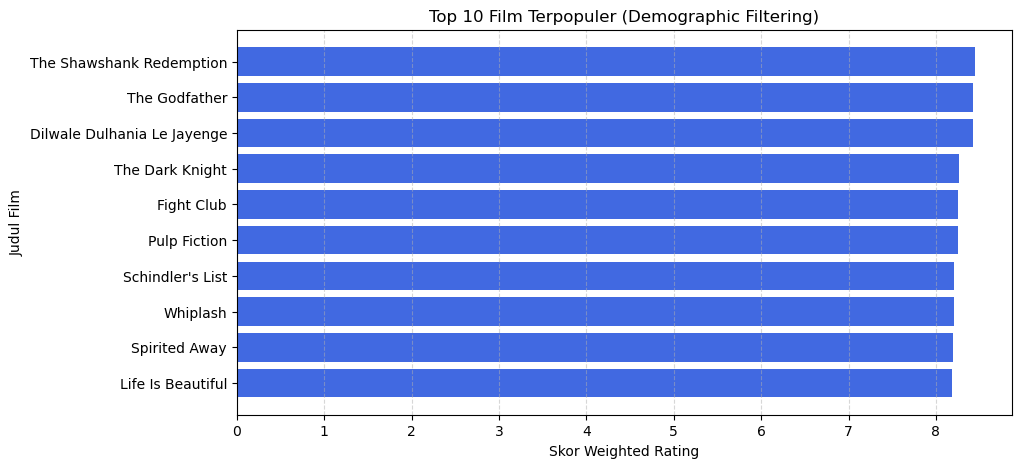

In [6]:
plt.figure(figsize=(10, 5))
top_movies = qualified_movies.head(10)
plt.barh(top_movies['title'].iloc[::-1], top_movies['score'].iloc[::-1], color='royalblue')
plt.xlabel("Skor Weighted Rating")
plt.ylabel("Judul Film")
plt.title("Top 10 Film Terpopuler (Demographic Filtering)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

---

## 3. Content-Based Filtering

Sistem rekomendasi ini bekerja dengan mencari film lain yang mirip dengan film yang disukai user berdasarkan profil konten film tersebut (seperti genre, sutradara, pemain utama, kata kunci tema, dan overview ringkasan cerita).

### Parsing Kolom JSON ke Python List
Kolom data `genres`, `keywords`, `cast`, dan `crew` disimpan dalam bentuk string representasi JSON. Kita akan mengonversinya menjadi tipe struktur data list/dictionary Python menggunakan library bawaan `ast.literal_eval`.

In [7]:
# Konversi kolom string JSON menjadi objek list Python
features = ['cast', 'crew', 'keywords', 'genres']
for feature in features:
    df[feature] = df[feature].apply(ast.literal_eval)

### Mengekstrak Fitur-Fitur Penting

Kita akan mengekstrak data:
1. Nama Sutradara (director) dari kolom `crew`.
2. Maksimal 3 Aktor Utama dari kolom `cast`.
3. Seluruh nama genre dari `genres`.
4. Seluruh kata kunci penting dari `keywords`.

In [8]:
# Ekstraksi nama sutradara (director)
def get_director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']
    return np.nan

df['director'] = df['crew'].apply(get_director)

# Ambil top 3 cast
def get_list(x):
    if isinstance(x, list):
        names = [i['name'] for i in x]
        if len(names) > 3:
            names = names[:3]
        return names
    return []

df['cast'] = df['cast'].apply(get_list)
df['keywords'] = df['keywords'].apply(lambda x: [i['name'] for i in x])
df['genres'] = df['genres'].apply(lambda x: [i['name'] for i in x])

df[['title', 'director', 'cast', 'keywords', 'genres']].head(3)

,title,director,cast,keywords,genres
0,Toy Story,John Lasseter,"[Tom Hanks, Tim Allen, Don Rickles]","[jealousy, toy, boy, friendship, friends, riva...","[Animation, Comedy, Family]"
1,Jumanji,Joe Johnston,"[Robin Williams, Jonathan Hyde, Kirsten Dunst]","[board game, disappearance, based on children'...","[Adventure, Fantasy, Family]"
2,Grumpier Old Men,Howard Deutch,"[Walter Matthau, Jack Lemmon, Ann-Margret]","[fishing, best friend, duringcreditsstinger, o...","[Romance, Comedy]"


### Pembersihan Spasi & Lowercase

Untuk menghindari bias pencocokan nama depan yang sama (misalnya "Johnny Depp" dan "Johnny Galecki"), kita menghapus spasi di antara nama sehingga menyatu (menjadi `johnnydepp` dan `johnnygalecki`) dan mengubah seluruh teks menjadi huruf kecil.

In [9]:
def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    else:
        if isinstance(x, str):
            return str.lower(x.replace(" ", ""))
        else:
            return ''

features_to_clean = ['cast', 'keywords', 'director', 'genres']
for feature in features_to_clean:
    df[feature] = df[feature].apply(clean_data)

df[['title', 'director', 'cast', 'keywords', 'genres']].head(3)

,title,director,cast,keywords,genres
0,Toy Story,johnlasseter,"[tomhanks, timallen, donrickles]","[jealousy, toy, boy, friendship, friends, riva...","[animation, comedy, family]"
1,Jumanji,joejohnston,"[robinwilliams, jonathanhyde, kirstendunst]","[boardgame, disappearance, basedonchildren'sbo...","[adventure, fantasy, family]"
2,Grumpier Old Men,howarddeutch,"[waltermatthau, jacklemmon, ann-margret]","[fishing, bestfriend, duringcreditsstinger, ol...","[romance, comedy]"


### Membuat Metadata Soup

Kita menggabungkan seluruh fitur metadata yang telah dibersihkan (`keywords`, `cast`, `director`, `genres`, beserta deskripsi ringkas `overview`) menjadi satu kesatuan teks berwujud string tunggal yang kita namakan `soup`.

**Catatan Optimasi Memori**: Karena jumlah film pada dataset sangat besar (~45.000), matriks kemiripan Cosine Similarity ukuran $45000 \times 45000$ dapat menyebabkan crash memori (OOM). Oleh karena itu, kita membatasi analisis pada **top 15.000 film paling populer** berdasarkan skor popularitas.

In [10]:
def create_soup(x):
    return ' '.join(x['keywords']) + ' ' + ' '.join(x['cast']) + ' ' + x['director'] + ' ' + ' '.join(x['genres']) + ' ' + str(x['overview'])

df['soup'] = df.apply(create_soup, axis=1)
df['soup'] = df['soup'].fillna('')

# Batasi ke top 15.000 film terpopuler untuk menghindari Out of Memory (OOM)
df_content = df.copy()
df_content = df_content.sort_values('popularity', ascending=False).head(15000).reset_index(drop=True)
print("Final shape for Content-Based:", df_content.shape)

Final shape for Content-Based: (15000, 29)


### Vektorisasi TF-IDF dan Kalkulasi Cosine Similarity

Kita mengekstrak fitur kata/term menggunakan `TfidfVectorizer` untuk menghitung representasi matematis dari dokumen soup, lalu menghitung kecocokan kosinus (`cosine_similarity`) antar seluruh film tersebut.

In [11]:
# Ekstraksi fitur menggunakan TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_content['soup'])

# Hitung Cosine Similarity Matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine Similarity Matrix shape:", cosine_sim.shape)

Cosine Similarity Matrix shape: (15000, 15000)


### Membuat Fungsi Rekomendasi

Kita memetakan judul film ke indeks baris matriks kemiripan untuk menarik 10 film dengan kemiripan visual dan deskripsi terdekat.

In [12]:
# Petakan judul film ke indeks dataset
indices = pd.Series(df_content.index, index=df_content['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in indices:
        return "Film tidak ditemukan dalam database content-based."
    
    # Dapatkan indeks dari film
    idx = indices[title]
    
    # Dapatkan nilai similarity film tersebut terhadap semua film
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Urutkan berdasarkan skor kemiripan terbesar
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Ambil 10 film teratas (indeks ke-0 adalah film itu sendiri)
    sim_scores = sim_scores[1:11]
    
    movie_indices = [i[0] for i in sim_scores]
    
    # Tampilkan judul film
    return df_content['title'].iloc[movie_indices]

### Menguji Rekomendasi Content-Based

Kita lakukan uji coba dengan memasukkan film fiksi ilmiah populer seperti *The Dark Knight Rises* untuk mengamati film-film superhero dan film besutan Christopher Nolan lainnya yang direkomendasikan.

In [13]:
print("Rekomendasi untuk 'The Dark Knight Rises':")
get_recommendations('The Dark Knight Rises')

Rekomendasi untuk 'The Dark Knight Rises':


14740                 The Dark Knight
14176                  Batman Returns
10001                   Batman Begins
14629                  Batman Forever
13780                          Batman
3086       Batman: Under the Red Hood
6125                 Batman: Year One
13913           The Lego Batman Movie
10846           DC Showcase: Catwoman
2759     Batman: Mask of the Phantasm
Name: title, dtype: object

---

## 4. Collaborative Filtering (Keras Embedding)

Sistem rekomendasi berbasis Collaborative Filtering mengacu pada kecenderungan perilaku sekelompok pengguna lain yang mirip. Kita akan membangun model Neural Collaborative Filtering berbasis **Keras Embedding** yang melatih vector representasi laten user dan film dari data rating interaksi.

### Load Dataset Ratings Small
Kita memuat `ratings_small.csv` yang berisi riwayat penilaian film (rentang rating 1.0 - 5.0) dan memetakan ID user maupun ID film menjadi index berurutan.

In [14]:
ratings = pd.read_csv("data/ratings_small.csv")
print("Ratings dataset shape:", ratings.shape)

# Encode user IDs
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
user_encoded2user = {i: x for i, x in enumerate(user_ids)}

# Encode movie IDs
movie_ids = ratings['movieId'].unique().tolist()
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)}

ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['movie'] = ratings['movieId'].map(movie2movie_encoded)

num_users = len(user2user_encoded)
num_movies = len(movie2movie_encoded)
print(f"Jumlah User unik: {num_users}, Jumlah Film unik dengan rating: {num_movies}")

Ratings dataset shape: (100004, 4)
Jumlah User unik: 671, Jumlah Film unik dengan rating: 9066


### Preprocessing & Split Train-Validation

Kita mengambil input data koordinat user & movie, menormalisasi nilai target rating (skala 1-5) menjadi rentang float [0.0, 1.0] untuk mempermudah konvergensi model neural network saat optimasi, lalu membaginya menjadi 80% data training dan 20% data validasi.

In [15]:
from sklearn.model_selection import train_test_split

x = ratings[['user', 'movie']].values
y = ratings['rating'].values

# Normalisasi target rating ke rentang 0 sampai 1
min_rating = min(y)
max_rating = max(y)
y_normalized = (y - min_rating) / (max_rating - min_rating)

# Split dataset
x_train, x_val, y_train, y_val = train_test_split(
    x, y_normalized, test_size=0.2, random_state=42
)

print("Train size:", x_train.shape)
print("Validation size:", x_val.shape)

Train size: (80003, 2)
Validation size: (20001, 2)


### Membangun Kelas Model RecommenderNet Keras

Kita mewarisi kelas `tf.keras.Model` untuk menyusun struktur jaringan embedding. Model ini akan memetakan user embedding dan movie embedding (masing-masing berdimensi latent `embedding_size`), lalu mengalikan kedua representasi laten tersebut (dot product) dan menambahkan user bias serta movie bias. Aktivasi akhir Sigmoid digunakan untuk menghasilkan output estimasi rating ternormalisasi [0, 1].

In [16]:
class RecommenderNet(tf.keras.Model):
    def __init__(self, num_users, num_movies, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = embedding_size
        
        # Inisialisasi User Embedding & User Bias
        self.user_embedding = tf.keras.layers.Embedding(
            num_users,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6),
        )
        self.user_bias = tf.keras.layers.Embedding(num_users, 1)
        
        # Inisialisasi Movie Embedding & Movie Bias
        self.movie_embedding = tf.keras.layers.Embedding(
            num_movies,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6),
        )
        self.movie_bias = tf.keras.layers.Embedding(num_movies, 1)
        
    def call(self, inputs):
        # Inputs berisi koordinat [user_index, movie_index]
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        movie_vector = self.movie_embedding(inputs[:, 1])
        movie_bias = self.movie_bias(inputs[:, 1])
        
        # Hitung dot product (element-wise multiplication lalu kurangi sum sepanjang dimensi axis=1)
        dot_user_movie = tf.reduce_sum(user_vector * movie_vector, axis=1)
        dot_user_movie = tf.expand_dims(dot_user_movie, -1)
        
        # Jumlahkan bias
        x = dot_user_movie + user_bias + movie_bias
        
        # Gunakan sigmoid agar output bernilai antara 0 dan 1
        return tf.nn.sigmoid(x)

### Melatih Model Neural Collaborative Filtering

Kita mengompilasi model menggunakan loss function **Binary Cross Entropy** (sesuai output sigmoid) dan optimizer Adam, kemudian melatihnya selama 5 epoch dengan batch size 64.

In [17]:
# Set parameter embedding
EMBEDDING_SIZE = 50

model = RecommenderNet(num_users, num_movies, EMBEDDING_SIZE)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
)

# Train Model
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=5,
    verbose=1,
    validation_data=(x_val, y_val)
)

Epoch 1/5



   1/1251 ━━━━━━━━━━━━━━━━━━━━ 25:49 1s/step - loss: 0.6933


  22/1251 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6938  


  43/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6935


  64/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6931

...


1180/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5457


1202/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5457


1224/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5457


1245/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5457


1251/1251 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5457 - val_loss: 0.5933


### Memplot Hasil Kurva Loss Training vs Validation

Grafik ini memvisualisasikan penurunan nilai error selama masa pembelajaran model.

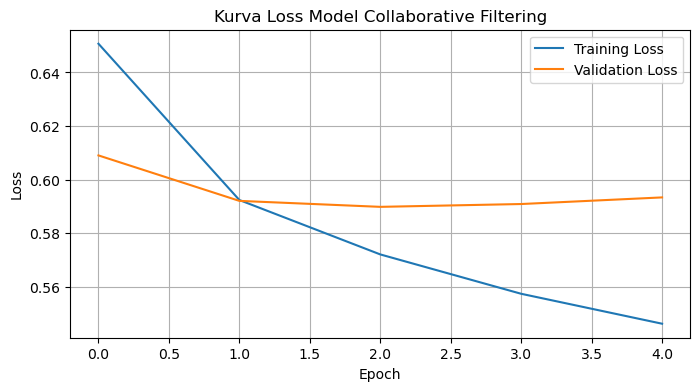

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Kurva Loss Model Collaborative Filtering")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Memberikan Rekomendasi Film Personalisasi untuk User Tertentu

Kita dapat memilih salah satu user secara acak (misalnya user dengan ID 5), mengidentifikasi film-film yang belum pernah ia tonton, kemudian menyodorkannya ke model untuk diestimasi rating tertingginya. Indeks rating tertinggi tersebut kita petakan kembali ke dataset film untuk menampilkan 10 film rekomendasi teratas untuk user bersangkutan.

In [19]:
# Ambil contoh User acak
user_id = 5

# Temukan film yang sudah ditonton oleh user tersebut
movies_watched_by_user = ratings[ratings.userId == user_id]

# Temukan film yang BELUM ditonton oleh user
movies_not_watched = df[~df['id'].isin(movies_watched_by_user.movieId.values)]['id'].values
movies_not_watched = list(set(movies_not_watched).intersection(set(movie2movie_encoded.keys())))

# Buat array pasangan [user_idx, movie_idx]
user_encoder = user2user_encoded.get(user_id)
user_movie_array = np.array([[user_encoder, movie2movie_encoded.get(x)] for x in movies_not_watched])

# Lakukan prediksi rating
ratings_pred = model.predict(user_movie_array).flatten()

# Ambil 10 indeks prediksi rating tertinggi
top_ratings_indices = ratings_pred.argsort()[-10:][::-1]
recommended_movie_ids = [movies_not_watched[x] for x in top_ratings_indices]

print(f"=== Top 10 Rekomendasi Film untuk User ID: {user_id} ===")
recommended_movies = df[df['id'].isin(recommended_movie_ids)]
for index, row in recommended_movies.head(10).iterrows():
    print(f"- {row['title']} ({row['genres']})")


 1/87 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step


87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step


87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


=== Top 10 Rekomendasi Film untuk User ID: 5 ===
- Once Were Warriors (['drama'])
- The 39 Steps (['action', 'thriller', 'mystery'])
- The Million Dollar Hotel (['drama', 'thriller'])
- Monsoon Wedding (['comedy', 'drama', 'romance'])
- On Guard (['drama', 'adventure'])
- The Passion of Joan of Arc (['drama', 'history'])
- Big Fish (['adventure', 'fantasy', 'drama'])
- Count Dracula (['horror'])
- Don't Look Down (['drama', 'romance'])
- The Tunnel (['sciencefiction'])
